# House Price Prediction & Analysis: Bengaluru

**Goal:** predict the price of a house in Bengaluru from its location, size, number of bedrooms (BHK), bathrooms and other details, and understand which factors affect the price the most.

**Dataset:** *Bengaluru House price data* by Amitabh Ajoy on Kaggle. It has 13,320 houses; **price is in ₹ lakhs** (1 lakh = ₹1,00,000).

**Steps:** load the data → clean it → explore it with charts → train and compare models → predict.

In [1]:
import sys
sys.path.append("..")          # so we can import our own cleaning code from src/

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_prep import (load_raw, basic_clean, convert_sqft, parse_bhk,
                           add_price_per_sqft, group_rare_locations, remove_outliers)

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 20)

## 1. Loading the Data

In [2]:
raw = load_raw("../data/Bengaluru_House_Data.csv")
print("Rows and columns:", raw.shape)
raw.head()

Rows and columns: (13320, 9)


,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [3]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  str    
 1   availability  13320 non-null  str    
 2   location      13319 non-null  str    
 3   size          13304 non-null  str    
 4   society       7818 non-null   str    
 5   total_sqft    13320 non-null  str    
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), str(6)
memory usage: 1.6 MB


In [4]:
print("Missing values in each column:")
raw.isnull().sum()

Missing values in each column:


area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

## 2. Data Cleaning

The raw data has several problems that must be fixed before analysis:

| Problem | Example | What we do |
|---|---|---|
| Duplicate rows | 529 exact copies | Remove them |
| `society` mostly empty | ~40% missing | Drop the column |
| `size` is text | "2 BHK", "4 Bedroom" | Take the number → `bhk` |
| `total_sqft` is text | "1133 - 1384", "34.46Sq. Meter" | Average ranges, convert units to sq ft |
| `availability` has dates | "18-Dec" | Turn into `ready_to_move` (1 = ready, 0 = under construction) |
| Missing `bath` / `balcony` | 73 / 609 rows | Drop rows without bath; fill balcony with the most common value |

In [5]:
print("Duplicate rows:", raw.duplicated().sum())
print("Unique values of size:", raw["size"].dropna().unique()[:8])

Duplicate rows: 529
Unique values of size: <ArrowStringArray>
[    '2 BHK', '4 Bedroom',     '3 BHK',     '4 BHK', '6 Bedroom', '3 Bedroom',
     '1 BHK',      '1 RK']
Length: 8, dtype: str


Our `parse_bhk` and `convert_sqft` functions handle the text values:

In [6]:
for size in ["2 BHK", "4 Bedroom", "1 RK"]:
    print(f"{size!r:14} -> {parse_bhk(size)} BHK")
print()
for sqft in ["1056", "1133 - 1384", "34.46Sq. Meter", "1Acres"]:
    print(f"{sqft!r:18} -> {convert_sqft(sqft)} sq ft")

'2 BHK'        -> 2 BHK
'4 Bedroom'    -> 4 BHK
'1 RK'         -> 1 BHK

'1056'             -> 1056.0 sq ft
'1133 - 1384'      -> 1258.5 sq ft
'34.46Sq. Meter'   -> 370.923994 sq ft
'1Acres'           -> 43560.0 sq ft


In [7]:
df = basic_clean(raw)
print("After basic cleaning:", df.shape)
df.head()

After basic cleaning: (12717, 8)


,area_type,location,total_sqft,bath,balcony,price,bhk,ready_to_move
0,Super built-up Area,Electronic City Phase II,1056.0,2,1,39.07,2,0
1,Plot Area,Chikka Tirupathi,2600.0,5,3,120.00,4,1
2,Built-up Area,Uttarahalli,1440.0,2,3,62.00,3,1
3,Super built-up Area,Lingadheeranahalli,1521.0,3,1,95.00,3,1
4,Super built-up Area,Kothanur,1200.0,2,1,51.00,2,1


### Price per square foot
A new column, `price_per_sqft` in rupees, makes houses of different sizes comparable. Since price is in lakhs: `price_per_sqft = price × 1,00,000 ÷ total_sqft`.

In [8]:
df = add_price_per_sqft(df)
df[["location", "total_sqft", "price", "price_per_sqft"]].head()

,location,total_sqft,price,price_per_sqft
0,Electronic City Phase II,1056.0,39.07,3699.810606
1,Chikka Tirupathi,2600.0,120.00,4615.384615
2,Uttarahalli,1440.0,62.00,4305.555556
3,Lingadheeranahalli,1521.0,95.00,6245.890861
4,Kothanur,1200.0,51.00,4250.000000


### Grouping rare locations
There are over 1,300 locations and many have only 1 or 2 houses. A model cannot learn from so few examples, so locations with 10 or fewer houses are grouped as **"Other"**.

In [9]:
print("Locations before:", df["location"].nunique())
df = group_rare_locations(df)
print("Locations after:", df["location"].nunique())

Locations before: 1293
Locations after: 234


### Removing outliers
Some houses are clearly unrealistic, for example a "3 BHK" listed as 6,53,400 sq ft (15 acres). We remove:
1. houses above **10,000 sq ft** (farm land or typing errors)
2. houses with **less than 300 sq ft per bedroom**
3. houses with **more bathrooms than bedrooms + 2**
4. houses whose price per sq ft is far from **the normal range of their location** (outside mean ± 1 standard deviation)

In [10]:
print("Largest areas before removing outliers:")
print(df.nlargest(3, "total_sqft")[["location", "total_sqft", "bhk", "price"]])

before = len(df)
df = remove_outliers(df)
print(f"\nRows before: {before}, after: {len(df)}, removed: {before - len(df)}")

Largest areas before removing outliers:
              location  total_sqft  bhk  price
1086             Other  1306800.00    2   29.5
648            Arekere  1123031.25    9  265.0
7001  Thyagaraja Nagar   653400.00    8  290.0

Rows before: 12717, after: 9872, removed: 2845


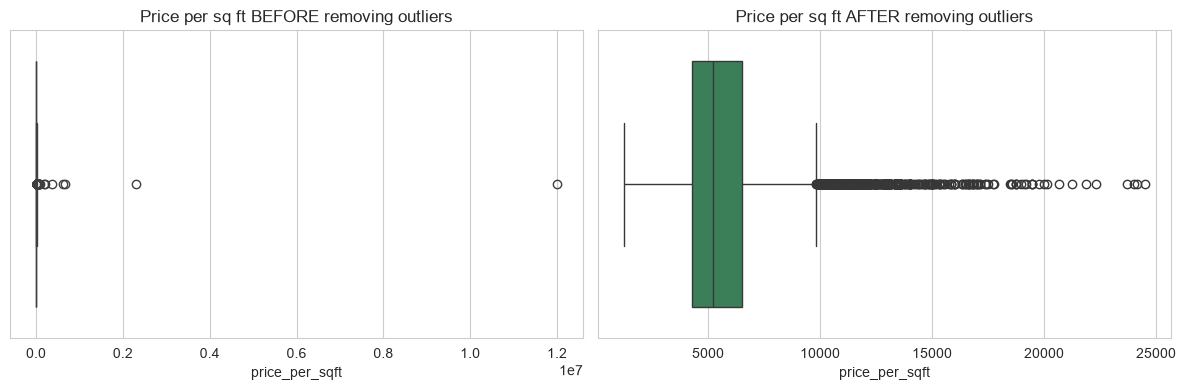

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
before_df = add_price_per_sqft(group_rare_locations(basic_clean(raw)))
sns.boxplot(x=before_df["price_per_sqft"], ax=axes[0])
axes[0].set_title("Price per sq ft BEFORE removing outliers")
sns.boxplot(x=df["price_per_sqft"], ax=axes[1], color="seagreen")
axes[1].set_title("Price per sq ft AFTER removing outliers")
plt.tight_layout()
plt.show()

After cleaning, **9,872 houses** remain in **234 locations**. Removing outliers took out the extreme values that would have misled the model.

## 3. Exploratory Data Analysis

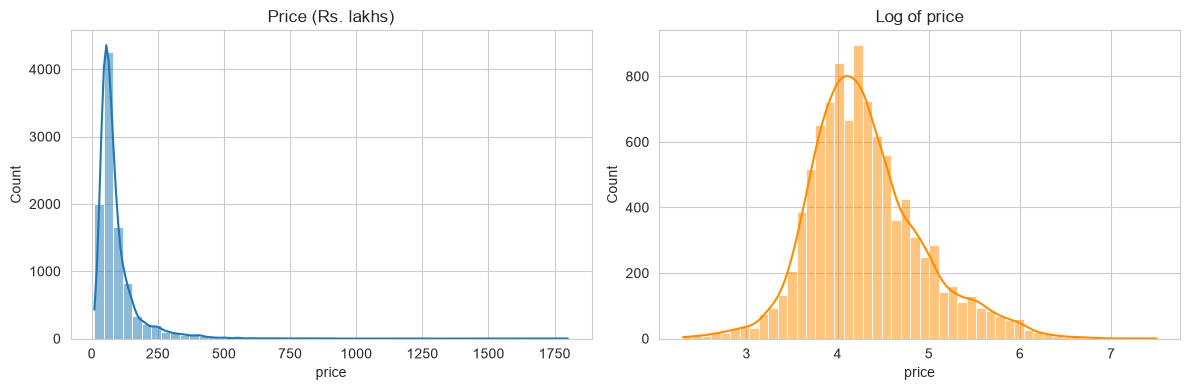

Skewness of price: 4.4 | after log: 0.62


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["price"], bins=50, kde=True, ax=axes[0])
axes[0].set_title("Price (Rs. lakhs)")
sns.histplot(np.log(df["price"]), bins=50, kde=True, ax=axes[1], color="darkorange")
axes[1].set_title("Log of price")
plt.tight_layout()
plt.show()
print("Skewness of price:", round(df["price"].skew(), 2), "| after log:", round(np.log(df["price"]).skew(), 2))

**Price is right-skewed:** most houses cost ₹40–100 lakhs, while a few cost several crores (skewness 4.4). Taking the log makes it much more balanced (0.62), which helps linear models later.

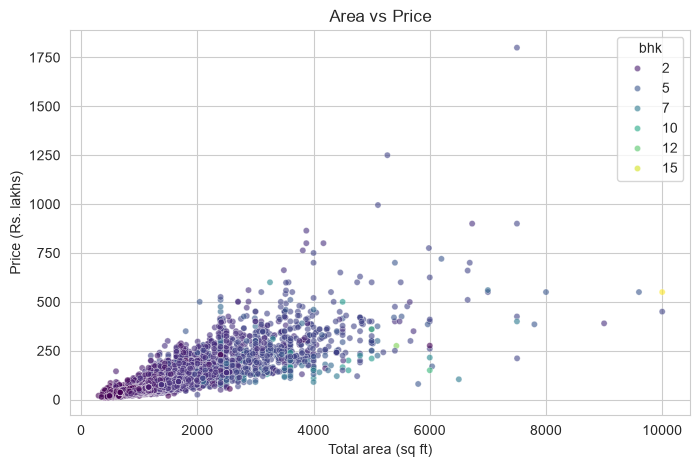

In [13]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="total_sqft", y="price", hue="bhk", palette="viridis", alpha=0.6, s=20)
plt.title("Area vs Price")
plt.xlabel("Total area (sq ft)")
plt.ylabel("Price (Rs. lakhs)")
plt.show()

**Bigger houses cost more.** Area has the strongest relationship with price, and houses with more bedrooms (lighter dots) sit higher up.

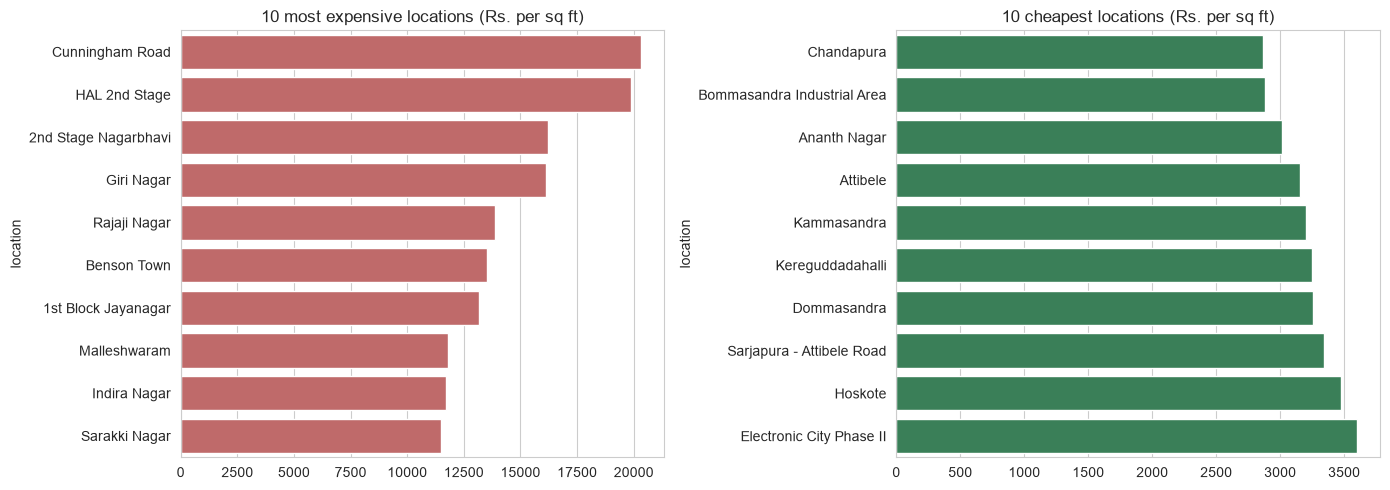

In [14]:
loc_pps = (df[df["location"] != "Other"]
           .groupby("location")["price_per_sqft"].mean()
           .sort_values(ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x=loc_pps.head(10).values, y=loc_pps.head(10).index, ax=axes[0], color="indianred")
axes[0].set_title("10 most expensive locations (Rs. per sq ft)")
cheapest = loc_pps.tail(10).sort_values()
sns.barplot(x=cheapest.values, y=cheapest.index, ax=axes[1], color="seagreen")
axes[1].set_title("10 cheapest locations (Rs. per sq ft)")
plt.tight_layout()
plt.show()

**Location changes the price a lot.** Cunningham Road (about ₹20,300 per sq ft) costs roughly **7 times** more than Chandapura (about ₹2,900 per sq ft). Central areas are the most expensive; outer areas like Chandapura and Bommasandra are the cheapest.

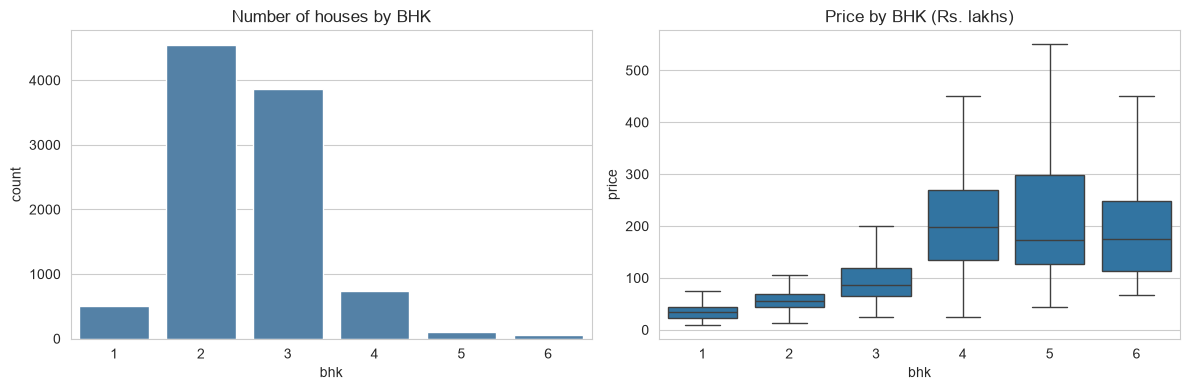

bhk
1     33.85
2     55.00
3     87.00
4    199.00
5    172.50
6    175.00
Name: price, dtype: float64


In [15]:
common = df[df["bhk"] <= 6]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=common, x="bhk", ax=axes[0], color="steelblue")
axes[0].set_title("Number of houses by BHK")
sns.boxplot(data=common, x="bhk", y="price", ax=axes[1], showfliers=False)
axes[1].set_title("Price by BHK (Rs. lakhs)")
plt.tight_layout()
plt.show()
print(df.groupby("bhk")["price"].median().head(6))

**2 and 3 BHK houses make up most of the data.** The median price rises steadily from ₹34 lakhs (1 BHK) to ₹55 lakhs (2 BHK), ₹87 lakhs (3 BHK) and ₹199 lakhs (4 BHK). Above 4 BHK there are very few houses, so prices there vary a lot.

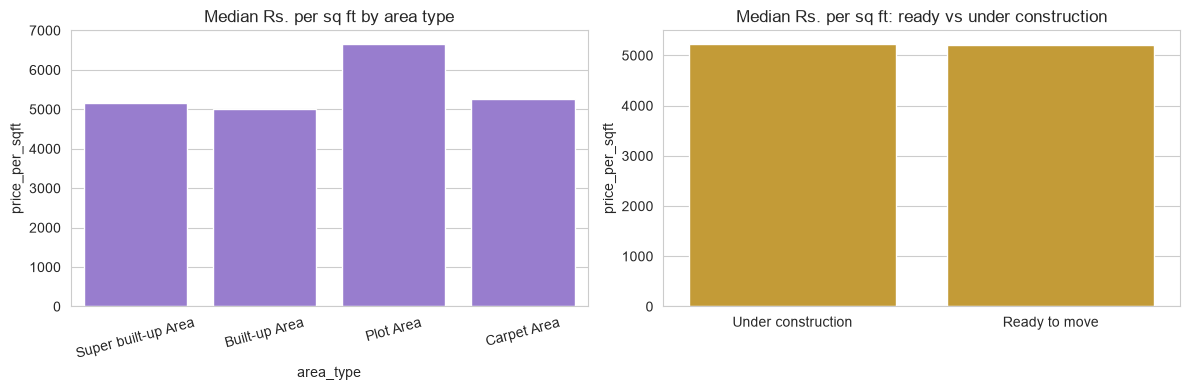

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=df, x="area_type", y="price_per_sqft", estimator="median", errorbar=None, ax=axes[0], color="mediumpurple")
axes[0].set_title("Median Rs. per sq ft by area type")
axes[0].tick_params(axis="x", rotation=15)
sns.barplot(x=df["ready_to_move"].map({1: "Ready to move", 0: "Under construction"}),
            y=df["price_per_sqft"], estimator="median", errorbar=None, ax=axes[1], color="goldenrod")
axes[1].set_title("Median Rs. per sq ft: ready vs under construction")
axes[1].set_xlabel("")
plt.tight_layout()
plt.show()

**Plots cost more per sq ft** (about ₹6,700) than flats (about ₹5,000–5,300), because the buyer gets the land too. **Ready-to-move and under-construction houses cost almost the same** per sq ft (₹5,200 vs ₹5,236).

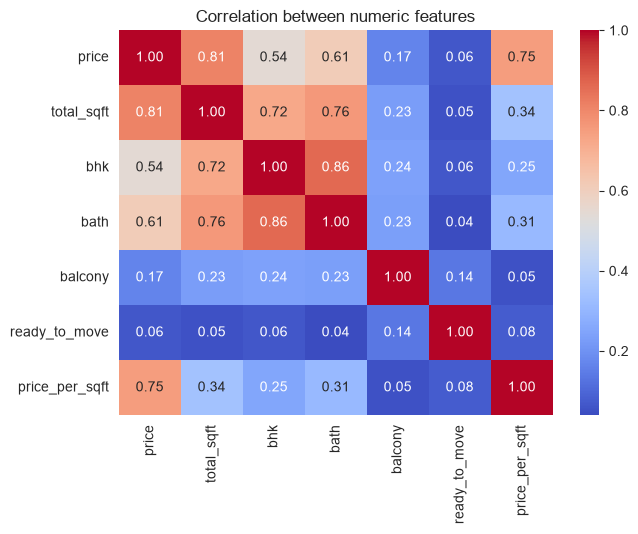

In [17]:
plt.figure(figsize=(7, 5))
numeric = df[["price", "total_sqft", "bhk", "bath", "balcony", "ready_to_move", "price_per_sqft"]]
sns.heatmap(numeric.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation between numeric features")
plt.show()

**Correlation with price:** total area 0.81, bathrooms 0.61, BHK 0.54. Balcony (0.17) and ready-to-move (0.06) have very little effect.

## Key insights so far
1. **Area** is the strongest numeric factor in house price.
2. **Location** matters enormously: the same area can cost 7 times more in a central location.
3. Price rises with **BHK and bathrooms**, but they are linked to area.
4. **Plots** are pricier per sq ft than flats; **ready-to-move status** hardly matters.
5. Price is **right-skewed**, so a log transformation will help some models.

In the next step we use these features to **train and compare models that predict the price**.

In [18]:
df.to_csv("../data/cleaned_house_data.csv", index=False)
print("Saved cleaned data:", df.shape)

Saved cleaned data: (9872, 9)
